# What Actually Drives Draft Position? Combining College Production & Athletic Testing

## Executive Summary
In Notebook 02, we discovered that college yards per game alone is a weak predictor of draft position. The 50-70 YPG baseline was consistent across almost every round, suggesting that **something else** separates first-rounders from Day 3 picks.

This notebook tests the hypothesis that **athletic testing (40-yard dash) combined with college production metrics** tells a more complete story. By blending these factors, we can identify which variables truly correlate with draft capital.

## Key Questions
1. Does 40 time matter more than college production?
2. Which college metric (YPG, YPC, or peak TDs) best predicts draft position?
3. Do players from Power 5 conferences get a draft boost regardless of production?
4. Can we identify the "perfect" prospect profile vs. the "overachiever" profile?

## Methodology
- **Data Sources:** College receiving stats, NFL Combine results, draft position (2017-2025)
- **Key Metrics:** 
  - College YPG (career average)
  - Yards per catch (efficiency)
  - Peak TD season (upside)
  - 40-yard dash (athletic ceiling)
  - Conference tier (competition level)
- **Filter:** Only players with verified 40 times (ensures apples-to-apples comparison)

In [6]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('nfl_analytics.db')

# combines college production, combine stats, and draft position
query = """
WITH player_data AS (
    SELECT 
        c.Player,
        c.Conf,
        -- college production
        AVG(c.RecYperG) as college_ypg,
        AVG(c.YperR) as yards_per_catch,
        MAX(c.RecTD) as peak_td,
        -- combine athletic testing
        com.`40yd` as forty_time,
        com.`3cone` as cone_time,
        com.Vertical,
        com.`Broad Jump` as broad_jump,
        -- draft information
        d.Player AS Pick,
        d.Round,
        d.Year as draft_year,
        -- conference tier
        CASE 
            WHEN c.Conf IN ('SEC', 'Big Ten') THEN 'SEC, BIG 10'
            WHEN c.Conf IN ('ACC', 'Big 12', 'Pac-12') THEN 'ACC, BIG 12, PAC 12'
            ELSE 'Other'
        END as conference_tier
    FROM college c
    LEFT JOIN draft_picks d ON d.Name = c.Player
    LEFT JOIN combine com ON com.Player = c.Player
    WHERE d.Year BETWEEN 2017 AND 2025
        AND com.`40yd` IS NOT NULL  -- Only players with 40 time
        AND com.`40yd` > 0
    GROUP BY c.Player
)
SELECT * FROM player_data
ORDER BY Pick;
"""


# execute and display
player_data = pd.read_sql_query(query, conn)

print("WR COLLEGE STATS, COMBINE STATS, AND SELECTION DATA (2017-2025)")
print("=" * 100)
print(player_data.head(10))


conn.close()

WR COLLEGE STATS, COMBINE STATS, AND SELECTION DATA (2017-2025)
           Player     Conf  college_ypg  yards_per_catch  peak_td  forty_time  \
0   Ja'Marr Chase      SEC   127.100000        21.200000       20        4.34   
1     Rome Odunze   Pac-12    83.600000        14.400000       13        4.45   
2  Garrett Wilson  Big Ten    72.500000        15.433333       12        4.38   
3     Chris Olave  Big Ten    80.900000        15.433333       13        4.39   
4     Jerry Jeudy      SEC    88.600000        17.200000       14        4.45   
5    Jahan Dotson  Big Ten    78.066667        16.033333       12        4.43   
6     CeeDee Lamb   Big 12    80.800000        18.900000       14        4.50   
7   Treylon Burks      SEC    75.433333        16.400000       11        4.55   
8  Kadarius Toney      SEC    89.500000        14.100000       10        4.39   
9    Jalen Reagor   Big 12    57.866667        15.466667        9        4.47   

   cone_time  Vertical  broad_jump  Pick  Ro

## Exploratory Data Analysis

Before diving into correlations, let's understand our data distributions. This helps us spot outliers and validate our metrics.

In [7]:
# summary statistics
print("SUMMARY STATISTICS")
print("=" * 60)
print(player_data[['college_ypg', 'yards_per_catch', 'peak_td', 'forty_time', 'Pick']].describe().round(2))

# check for correlations
print("\nCORRELATION WITH DRAFT POSITION")
print("=" * 60)
correlations = player_data[['college_ypg', 'yards_per_catch', 'peak_td', 'forty_time', 'Pick']].corr()['Pick'].sort_values(ascending=False)
print(correlations.to_string())

# distribution of 40 times by round
print("\nAVERAGE 40 TIME BY DRAFT ROUND")
print("=" * 60)
round_40 = player_data.groupby('Round')['forty_time'].agg(['mean', 'min', 'max']).round(2)
print(round_40.to_string())

SUMMARY STATISTICS
       college_ypg  yards_per_catch  peak_td  forty_time    Pick
count       167.00           167.00   167.00      167.00  167.00
mean         69.94            15.23     8.97        4.46  121.56
std          19.91             2.37     3.25        0.09   73.70
min          32.95            10.55     1.00        4.21    5.00
25%          54.72            13.35     7.00        4.40   56.00
50%          68.15            15.17     9.00        4.46  110.00
75%          83.25            16.64    11.00        4.51  185.00
max         140.40            21.20    20.00        4.73  258.00

CORRELATION WITH DRAFT POSITION
Pick               1.000000
forty_time         0.379406
yards_per_catch   -0.131656
college_ypg       -0.258702
peak_td           -0.362642

AVERAGE 40 TIME BY DRAFT ROUND
       mean   min   max
Round                  
1      4.42  4.21  4.55
2      4.42  4.28  4.61
3      4.45  4.27  4.65
4      4.45  4.34  4.60
5      4.48  4.37  4.73
6      4.49  4.33  4.61

### Key Takeaways from Exploratory Analysis

Before visualizing the data, let's understand what the numbers are telling us about what actually drives draft position:

**1. 40-yard dash time has the strongest correlation with draft position (r = 0.38)**
This is the biggest surprise. Athletic testing—specifically straight-line speed—correlates more strongly with where a receiver gets drafted than any college production metric we measured. The positive correlation means: **slower 40 times = later picks**.

**2. Peak touchdowns (r = -0.36) matters more than yards per game (r = -0.26)**
NFL teams appear to value a receiver's ability to find the end zone over pure volume stats. A single dominant TD season might signal more about a player's upside than consistent yardage accumulation.

**3. Yards per catch (r = -0.13) is essentially uncorrelated with draft position**
Efficiency metrics don't predict draft stock. Whether a receiver averages 12 yards per catch or 20, it barely moves the needle on draft day.

**4. The 40-time progression by round tells the same story**
| Round | Avg 40 Time |
|-------|-------------|
| 1 | 4.42 |
| 2 | 4.42 |
| 3 | 4.45 |
| 4 | 4.45 |
| 5 | 4.48 |
| 6 | 4.49 |
| 7 | 4.52 |

The trend is clear: **earlier rounds draft faster players**. Even Round 4's slight dip (4.45) is interesting—possibly the "value round" for fast players who fell due to other factors.

**The Big Picture:** These correlations confirm what we suspected in Notebook 2—college production alone doesn't drive draft position. Athletic testing (specifically speed) plays a major role. Now let's visualize this relationship to see the pattern with our own eyes.

### Scatter Plot
Now we need to plot it on a scatter plot to see what we can find! For this run, I am going to plot college yardage on the x axis, draft position on the y axis, and I will plot the 40 yard dash time by the size of each point. I will also make the color of each point different depending on how notable of a conference they are in.


#### LEGEND
| X AXIS | Y AXIS | Point Size | Point Color | 
| :--- | :--- | :--- | :--- |
| College YPG | Draft Position | 40 Yard Dash <br> BIG = Sub 4.3 sec <br> SMALL = Greater than 4.7 sec | Conference <br>RED = SEC, BIG 10<br> BLUE = ACC, BIG 12, PAC 12<br>GREEN = Other |

### What This Visualization Shows

Based on our correlation analysis, we expect to see:

- **Big dots (early picks) clustered near the TOP** of the plot (faster 40 times)
- **Big dots spread across the X-axis** (college YPG varies even among top picks)
- **Red dots (SEC/Big 10)** potentially overrepresented among early picks, even with similar numbers

If we see this pattern, it confirms: **NFL teams prioritize speed, then production, then conference pedigree.**

CREATING SCATTER PLOT: COLLEGE PRODUCTION vs DRAFT POSITION
Total players with data: 167
Pick range: 5 to 258



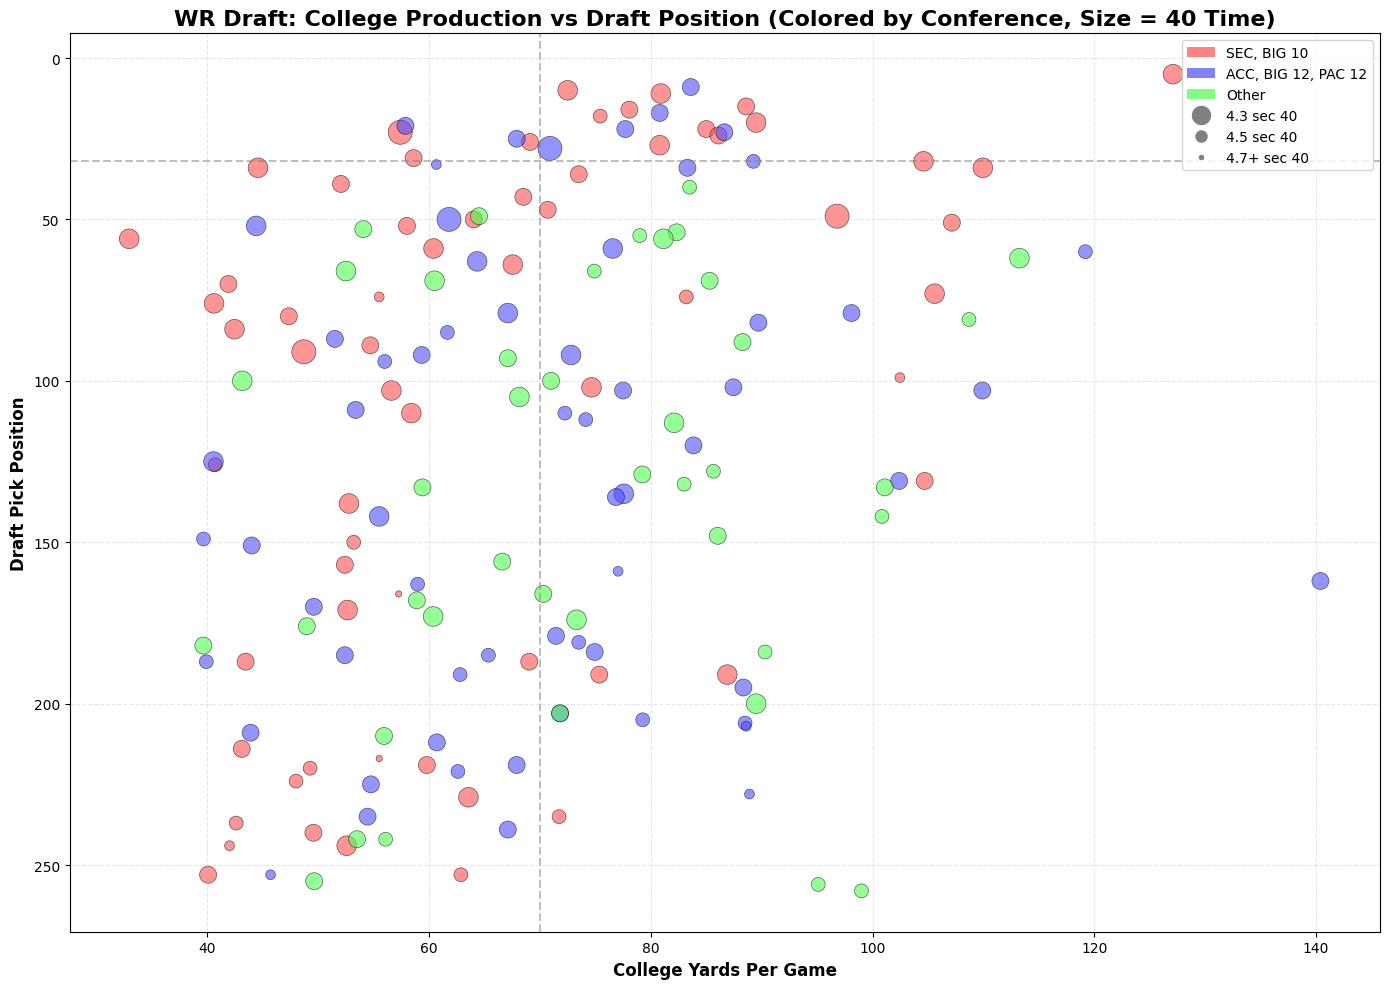


SUMMARY BY CONFERENCE TIER:
                     Count  Avg YPG  Avg 40 Time  Avg Pick
conference_tier                                           
ACC, BIG 12, PAC 12     62    71.05         4.48    128.21
Other                   41    73.99         4.45    134.37
SEC, BIG 10             64    66.27         4.45    106.92

Visualization saved as 'wr_draft_scatter_by_pick.png'


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def get_marker_size(dash):
    # BASED ON ROUNDS LAST YEAR
    if dash <= 4.3:
        return 300  # Top 10: huge
    elif dash <= 4.4:
        return 200  # Round 1: big
    elif dash <= 4.5:
        return 150  # Round 2: medium-large
    elif dash <= 4.6:
        return 100  # Round 3: medium
    elif dash <= 4.7:
        return 50   # Round 4: small
    elif dash <= 4.8:
        return 20   # Round 5: small
    elif dash <= 4.9:
        return 10   # Round 6: small
    else:
        return 5   # Round 7: tiny


print("CREATING SCATTER PLOT: COLLEGE PRODUCTION vs DRAFT POSITION")
print("=" * 60)

# first, let's check what's in player_data
print(f"Total players with data: {len(player_data)}")
print(f"Pick range: {player_data['Pick'].min()} to {player_data['Pick'].max()}")
print("\n" + "=" * 60)

# set up the plot
fig, ax = plt.subplots(figsize=(14, 10))

# define colors for conference tiers
conference_colors = {
    'SEC, BIG 10': '#FF4D4D',         # Red
    'ACC, BIG 12, PAC 12': '#4D4DFF', # Blue
    'Other': '#4DFF4D'                # Green
}

# define marker sizes based on 40 time (lower 40 time = bigger marker)
max_pick = player_data['forty_time'].max()
player_data['marker_size'] = player_data['forty_time'].apply(get_marker_size)

# create scatter plot for each conference tier
for tier, color in conference_colors.items():
    tier_data = player_data[player_data['conference_tier'] == tier]
    
    if len(tier_data) > 0:
        scatter = ax.scatter(
            tier_data['college_ypg'], 
            tier_data['Pick'],
            s=tier_data['marker_size'],  # Size by pick number
            c=color,
            alpha=0.6,
            edgecolors='black',
            linewidth=0.5,
            label=f"{tier} ({len(tier_data)} players)"
        )

# add labels for top 10 picks
#top_picks = player_data[player_data['Pick'] <= 10]
#for _, player in top_picks.iterrows():
#    ax.annotate(
#        f"{player['Player']} (#{player['Pick']})",
#        (player['college_ypg'], player['forty_time']),
#        xytext=(5, 5),
#        textcoords='offset points',
#        fontsize=9,
#        fontweight='bold',
#        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7)
#    )

# add a colorbar to explain marker sizes
# create a legend for pick ranges
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor='#FF4D4D', alpha=0.7, label='SEC, BIG 10'),
    Patch(facecolor='#4D4DFF', alpha=0.7, label='ACC, BIG 12, PAC 12'),
    Patch(facecolor='#4DFF4D', alpha=0.7, label='Other'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=15, label='4.3 sec 40'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='4.5 sec 40'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=5, label='4.7+ sec 40')
]

# customize the chart
ax.set_xlabel('College Yards Per Game', fontsize=12, fontweight='bold')
ax.set_ylabel('Draft Pick Position', fontsize=12, fontweight='bold')
ax.set_title('WR Draft: College Production vs Draft Position (Colored by Conference, Size = 40 Time)', 
             fontsize=16, fontweight='bold')

# invert y-axis (lower 40 time is better)
ax.invert_yaxis()

# add grid
ax.grid(True, alpha=0.3, linestyle='--')

# add legend
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

# add some reference lines (optional)
ax.axhline(y=32, color='gray', linestyle='--', alpha=0.5, label='End of Round 1')
ax.axvline(x=70, color='gray', linestyle='--', alpha=0.5, label='70 YPG threshold')

plt.tight_layout()
plt.savefig('wr_draft_scatter_by_pick.png', dpi=300, bbox_inches='tight')
plt.show()

# show summary statistics
print("\nSUMMARY BY CONFERENCE TIER:")
print("=" * 60)
summary = player_data.groupby('conference_tier').agg({
    'Player': 'count',
    'college_ypg': 'mean',
    'forty_time': 'mean',
    'Pick': 'mean'
}).round(2)
summary.columns = ['Count', 'Avg YPG', 'Avg 40 Time', 'Avg Pick']
print(summary.to_string())

print("\nVisualization saved as 'wr_draft_scatter_by_pick.png'")

***
## STILL NEEDS WORK
There hasn't been any significant findings in this notebook yet, so we will need to continue to work to try and find something significant!

***
## LINKS <br>
#### [PORTFOLIO](https://quinng8.github.io/nfl-draft-analytics/)
#### [Predictive NFL Success](https://quinng8.github.io/nfl-draft-analytics/04_predictive_NFL_success.html)